# ISS Projekt 2023/24

Honza Pavlus, Honza Brukner a Honza Černocký, ÚPGM FIT VUT

6.11. 2023



## 1. Úvod

V projektu budete pracovat se biomedicínskými signály a to konkrétně se signálem elektrokardiogramu EKG. Vyzkoušíte si filtraci tohoto druhu signálu, abyste dostali krásné EKG křivky, které můžete vidět ve filmech. Dále si zkusíte vybudovat jednoduchý, ale účinný detektor QRS a ti, kteří se vrhnou i na bonusový úkol, si zkusí odhalit srdeční patologii. K dispozici dostanete každý 3 nahrávky jednokanálového EKG signálu, jeden zdravý a dva s různými patologiemi.

Projekt je nejlépe možno řešit v Python-u a to přímo v dodaném Python notebooku, který si můžete zkopírovat do vlastního Google Colabu. Projekt je také možno řešit v Matlab-u, Octave, Julii, jazyce C, Java nebo v libovolném jiném programovacím či skriptovacím jazyce. Je možné použít libovolné knihovny. Projekt se nezaměřuje na “krásu programování”, není tedy nutné mít vše úhledně zabalené do okomentovaných funkcí (samozřejmě se ale okomentovaný kód lépe opravuje a to hlavně v případě podivných výsledků), ošetřené všechny chybové stavy, atd. Důležitý je výsledek.

**Vaši práci odevzdáváte vyexportovanou do dvou souborů: (1) do PDF souboru login.pdf, (2) do Python notebooku login.ipynb. PDF musí obsahovat výsledky prokazatelně vytvořené Vaším kódem.** V případě řešení projektu v jiném jazyce nebo prostředí než v dodaném Python notebooku, je prvním souborem protokol v PDF, druhý soubor je archiv s Vaším kódem. Ten musí být spustitelný na standardní fakultní distribuci Windows nebo Linuxu.

## 2. Teorie - před odevzdáním prosíme smazat včetně ilustračních obrázků.

Pokud znáte základní teorii okolo EKG signálů, můžete tuhle část přeskočit. Teorie je doopravdy stručná, neboť teorie EKG není cílem tohoto předmětu.

EKG signál má několik základních částí:
  

1.   P vlnu, která značí počátek kontrakce předsíní
2.   QRS komplex vln, který vzniká depolarizací komor (jejich stažením)
3.   T vlna jako poslední představuje repolarizaci komor (tedy jejich zpětné roztažení)

Nás bude zajímat především QRS komplex, který se ve spektru nachází mezi 10 Hz a 20 Hz. Z polohy QRS lze určit RR interval - vzdálenost mezi jednotlivými R vlnami. RR interval je přímo spojený se srdečním tepem. Na obrázku spektra EKG signálu můžete také vidět, na kterých frekvencích se nachází P a T vlna, kterou my ale v projektu odfiltrujeme.

EKG se snímá v několika základních rozloženích elektrodových svodů. V nemocnici se potkáte nejčastěji s 12 svodovým EKG. V projektu dostanete jeden z těchto svodů.


#### Popis EKG





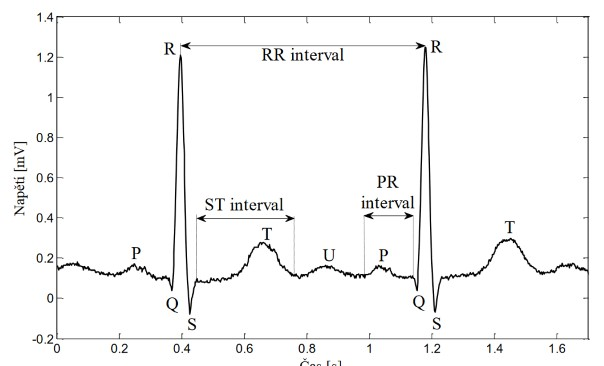

#### EKG ve spektru

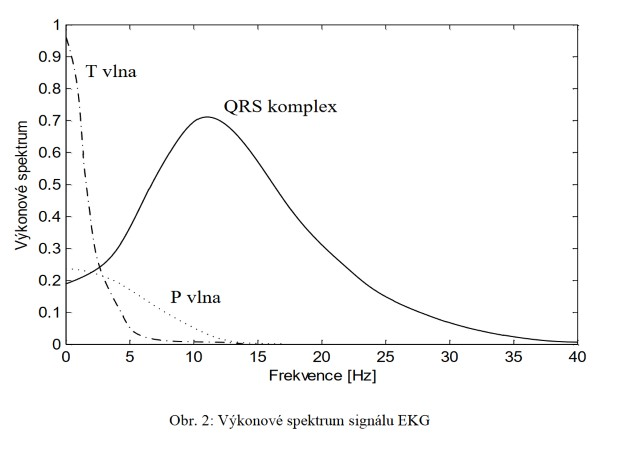

## 3. Vstup
Pro řešení projektu má každý student/ka k disposici osobní soubor se  zdravým signálem (sinusovým rytmem): ***login.wav***, kde login je váš xlogin popřípadě VUT číslo (pro studenty FSI). Dále jsou k disposici  ještě další dva signály: ***FIS.wav*** a ***KES.wav***. První signál obsahuje fibrilaci a druhý komorovou extrasystolu. Tyhle dva soubory jsou pro všechny společné a využijete je při řešení bonusového úkolu.

In [ ]:
#Načtení Vašeho signálu - xlogin99 nahraďte Vaším loginem
import soundfile as sf

!wget https://www.fit.vutbr.cz/study/courses/ISS/public/proj2023-24/xteich02.wav
!wget https://www.fit.vutbr.cz/study/courses/ISS/public/proj2023-24/FIB.wav
!wget https://www.fit.vutbr.cz/study/courses/ISS/public/proj2023-24/KES.wav

x, fs = sf.read("xteich02.wav")


--2023-12-03 09:30:32--  https://www.fit.vutbr.cz/study/courses/ISS/public/proj2023-24/xteich02.wav
Resolving www.fit.vutbr.cz (www.fit.vutbr.cz)... 147.229.9.23, 2001:67c:1220:809::93e5:917
Connecting to www.fit.vutbr.cz (www.fit.vutbr.cz)|147.229.9.23|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 10044 (9.8K) [audio/x-wav]
Saving to: ‘xteich02.wav.6’

xteich02.wav.6      100%[===================>]   9.81K  --.-KB/s    in 0s      

2023-12-03 09:30:33 (190 MB/s) - ‘xteich02.wav.6’ saved [10044/10044]

--2023-12-03 09:30:33--  https://www.fit.vutbr.cz/study/courses/ISS/public/proj2023-24/FIB.wav
Resolving www.fit.vutbr.cz (www.fit.vutbr.cz)... 147.229.9.23, 2001:67c:1220:809::93e5:917
Connecting to www.fit.vutbr.cz (www.fit.vutbr.cz)|147.229.9.23|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 10044 (9.8K) [audio/x-wav]
Saving to: ‘FIB.wav.2’

FIB.wav.2           100%[===================>]   9.81K  --.-KB/s    in 0s      

2023-12-0

## 4. Úkoly



### 4.1. [2.5b] Nahrání a zobrazení EKG signálu

Nezapomeňte na popisy os u jednotlivých grafů.

 a) [1b] Nahrajte EKG signál login.wav, vyberte 5-sekundový úsek a zobrazte ho v časové doméně. Pro nahrání signálu použijte knihovny numpy a soundfile.

--2023-12-17 20:47:29--  https://www.fit.vutbr.cz/study/courses/ISS/public/proj2023-24/xteich02.wav
Resolving www.fit.vutbr.cz (www.fit.vutbr.cz)... 147.229.9.23, 2001:67c:1220:809::93e5:917
Connecting to www.fit.vutbr.cz (www.fit.vutbr.cz)|147.229.9.23|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 10044 (9.8K) [audio/x-wav]
Saving to: ‘xteich02.wav’

xteich02.wav        100%[===================>]   9.81K  --.-KB/s    in 0s      

2023-12-17 20:47:32 (185 MB/s) - ‘xteich02.wav’ saved [10044/10044]



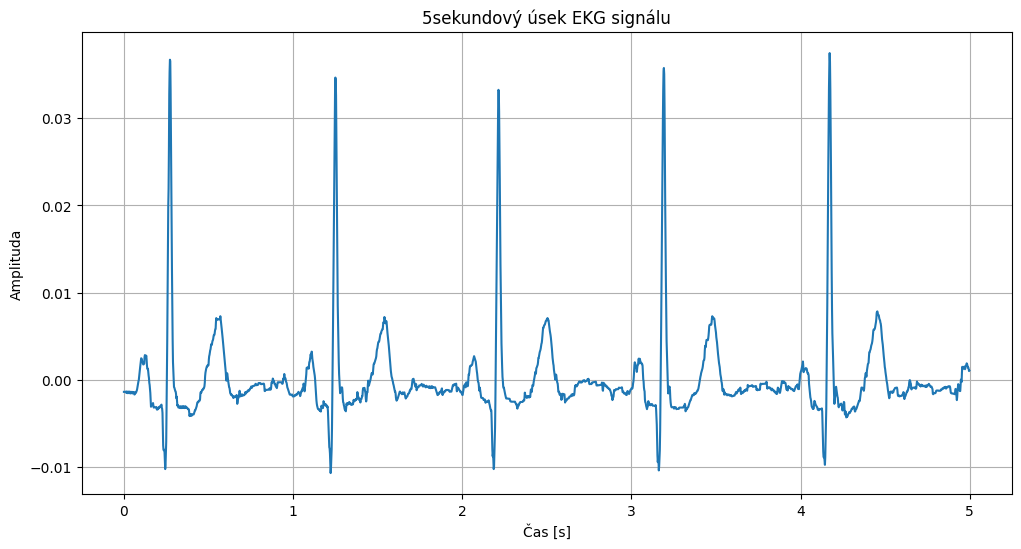

In [4]:
# Zde napište váš kód
import numpy as np
import soundfile as sf
import matplotlib.pyplot as plt

!wget https://www.fit.vutbr.cz/study/courses/ISS/public/proj2023-24/xteich02.wav

signal, samplerate = sf.read("xteich02.wav")

time_duration = 5
samples_to_select = samplerate * time_duration
segment = signal[:samples_to_select]

t = np.linspace(0, time_duration, len(segment), endpoint=False)

plt.figure(figsize=(12, 6))
plt.plot(t, segment)
plt.title('5sekundový úsek EKG signálu')
plt.xlabel('Čas [s]')
plt.ylabel('Amplituda')
plt.grid(True)
plt.show()

b) [1b] Spočítejte spektrum z 5 sekundového úseku nahraného signálu a zobrazte jej.

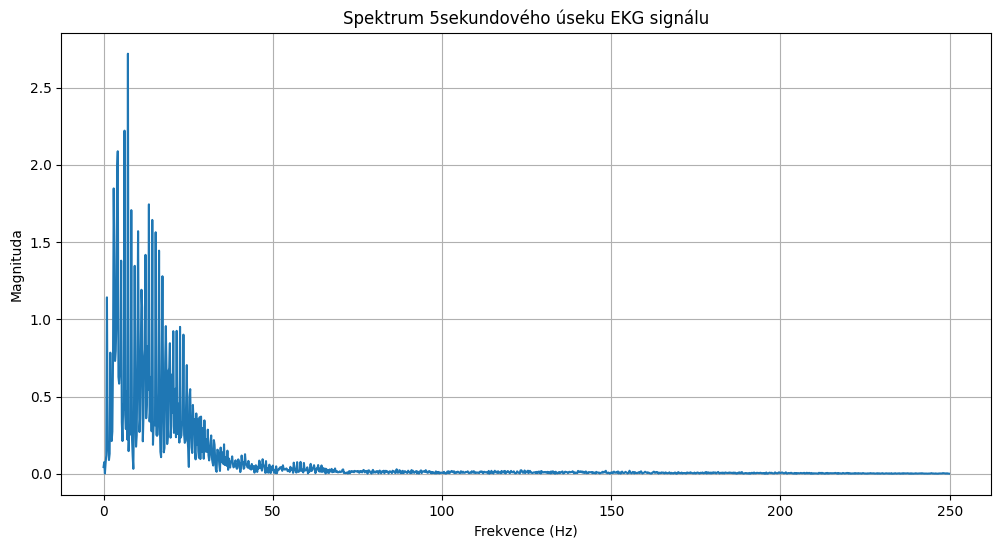

In [3]:
import numpy as np
import matplotlib.pyplot as plt
import soundfile as sf

# Načtení signálu
signal, samplerate = sf.read("xteich02.wav")

# Výběr 5-sekundového úseku
segment_length = 5 * samplerate
segment = signal[:segment_length]

# Funkce pro výpočet spektra signálu
def calculate_spectrum(signal, samplerate):
    freq_spectrum = np.fft.fft(signal)
    freq = np.fft.fftfreq(len(signal), d=1/samplerate)
    magnitude = np.abs(freq_spectrum)
    #magnitude_normalized = magnitude / np.max(magnitude)
    return freq, magnitude

# Výpočet spektra
freq, magnitude = calculate_spectrum(segment, samplerate)

# Vykreslení spektra
plt.figure(figsize=(12, 6))
plt.plot(freq[freq >= 0], magnitude[freq >= 0])
plt.title('Spektrum 5sekundového úseku EKG signálu')
plt.xlabel('Frekvence (Hz)')
plt.ylabel('Magnituda')
plt.grid(True)
plt.show()


 c) [0.5b] Ve spektru vidíte rušení na 50Hz nebo 60Hz a jejich harmonických frekvencích. Vysvětlete, čím je způsobeno.


Rušení na 50 nebo 60 Hz ve spektru je obvykle způsobeno elektrickým zářením ze síťového napájení a jeho harmonických frekvencí.

### 4.2. [3b] Převzorkujte nahraný signál



a) [2b] Převzorkujte signál na vzorkovací frekvenci 100 Hz, nezapomeňte na filtr pro antialiasing. Můžete například odstranit část spektra od $\frac{Fs}{2}$ nebo použít filtr dolní propusti.

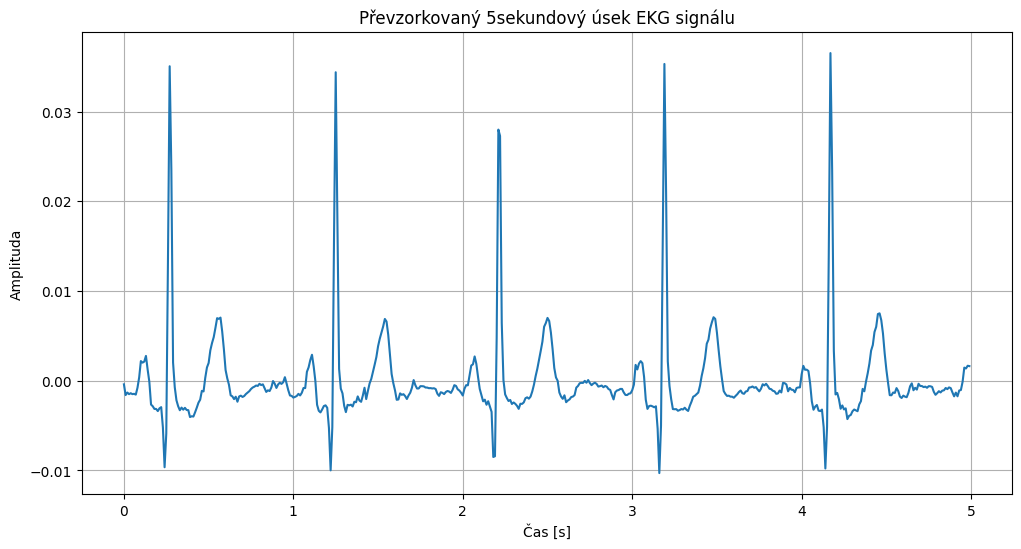

In [19]:
# Zde napište váš kód

from scipy import signal


# Nová vzorkovací frekvence
new_samplerate = 100  # Hz

# Vypočítáme počet bodů v převzorkovaném signálu
num_original_points = len(segment)
num_new_points = int(num_original_points * new_samplerate / samplerate)

# Použijeme funkci resample z knihovny scipy pro převzorkování signálu a aplikaci anti-aliasing filtru
resampled_signal = signal.resample(segment, num_new_points)

# Nový časový vektor pro vykreslení
t_resampled = np.linspace(0, time_duration, num=num_new_points, endpoint=False)

# Vykreslení převzorkovaného signálu
plt.figure(figsize=(12, 6))
plt.plot(t_resampled, resampled_signal)
plt.title('Převzorkovaný 5sekundový úsek EKG signálu')
plt.xlabel('Čas [s]')
plt.ylabel('Amplituda')
plt.grid(True)
plt.show()


b) [1b] Zobrazte 5 sekundový úsek původního a převzorkovaného signálu v časové doméně a zobrazte i jejich spektra.

--2023-12-17 21:29:28--  https://www.fit.vutbr.cz/study/courses/ISS/public/proj2023-24/xteich02.wav
Resolving www.fit.vutbr.cz (www.fit.vutbr.cz)... 147.229.9.23, 2001:67c:1220:809::93e5:917
Connecting to www.fit.vutbr.cz (www.fit.vutbr.cz)|147.229.9.23|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 10044 (9.8K) [audio/x-wav]
Saving to: ‘xteich02.wav.3’

xteich02.wav.3      100%[===================>]   9.81K  --.-KB/s    in 0s      

2023-12-17 21:29:30 (195 MB/s) - ‘xteich02.wav.3’ saved [10044/10044]



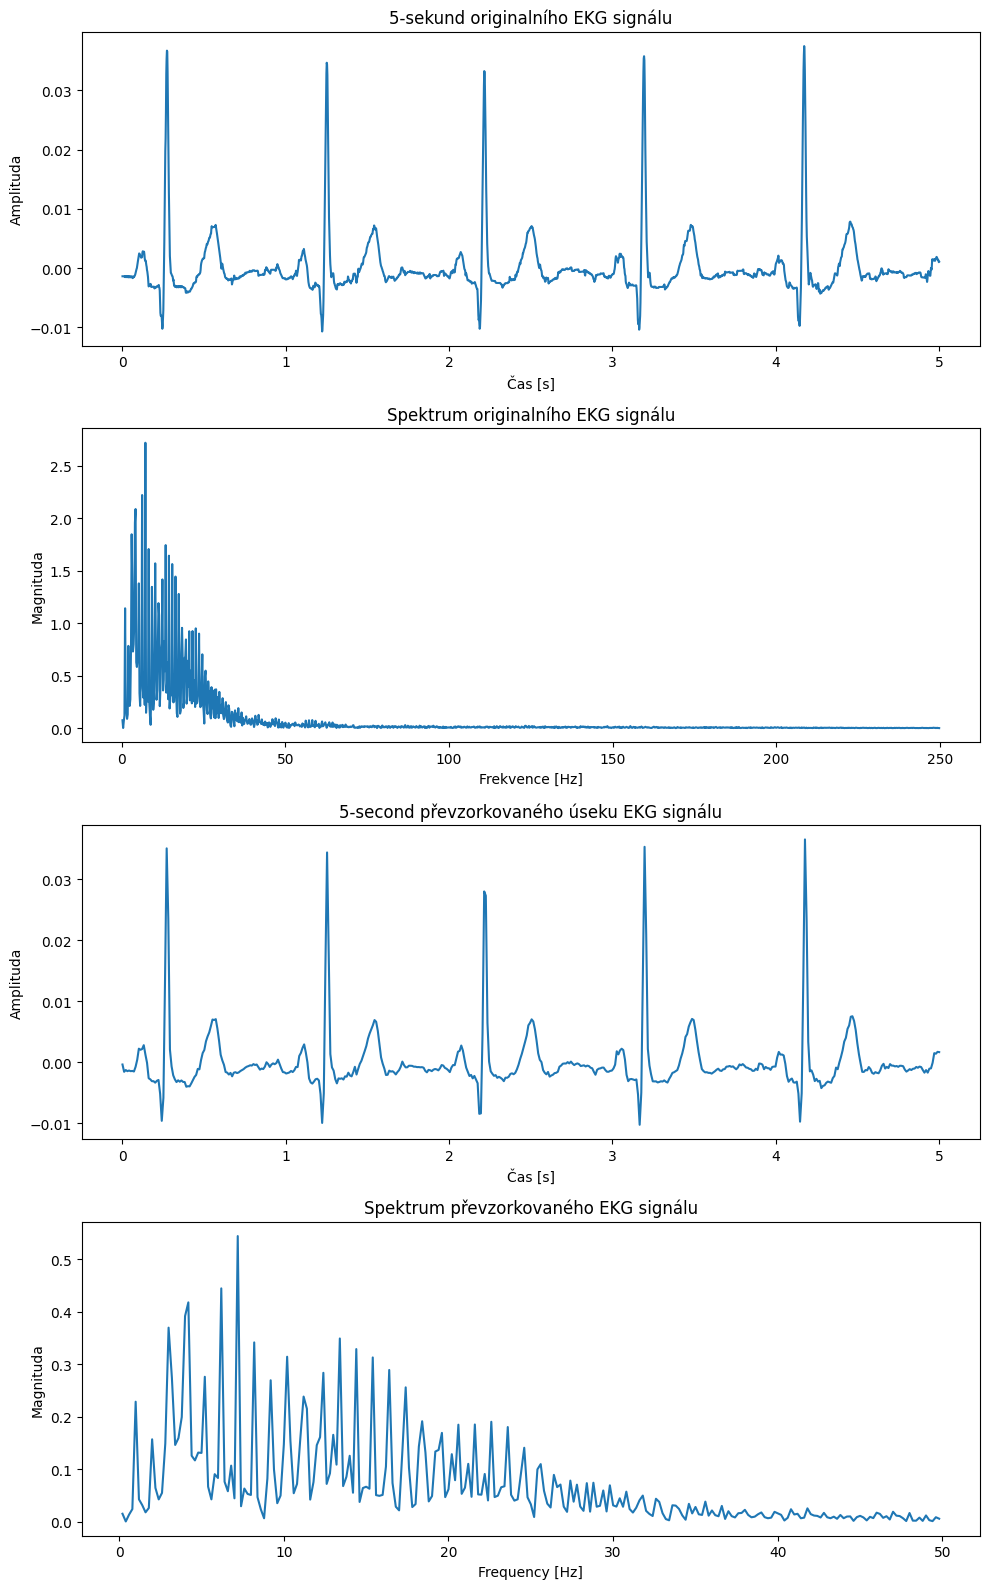

In [31]:
# Zde napište váš kód
import numpy as np
import matplotlib.pyplot as plt
import soundfile as sf
from scipy.signal import resample

# Načtení původního signálu
!wget https://www.fit.vutbr.cz/study/courses/ISS/public/proj2023-24/xteich02.wav

signal, original_samplerate = sf.read("xteich02.wav")

# Výběr 5 sekundového segmentu
segment_length = 5 * original_samplerate
original_signal = signal[:segment_length]

# Převzorkování signálu na 100 Hz
target_samplerate = 100
resampled_signal = resample(original_signal, int(segment_length * target_samplerate / original_samplerate))

# Výpočet spektra pro původní signál
frequencies_original = np.fft.fftfreq(len(original_signal), d=1/original_samplerate)
spectrum_original = np.fft.fft(original_signal)
positive_frequencies_original = frequencies_original > 0
magnitudes_original = np.abs(spectrum_original)

# Výpočet spektra pro převzorkovaný signál
frequencies_resampled = np.fft.fftfreq(len(resampled_signal), d=1/target_samplerate)
spectrum_resampled = np.fft.fft(resampled_signal)
positive_frequencies_resampled = frequencies_resampled > 0
magnitudes_resampled = np.abs(spectrum_resampled)

# Vytvoření grafů
fig, axs = plt.subplots(4, 1, figsize=(10, 16))  # Změna na 4 subplots

# Graf v časové doméně pro původní signál
axs[0].plot(np.linspace(0, 5, len(original_signal)), original_signal)
axs[0].set_title('5-sekund originalního EKG signálu')
axs[0].set_xlabel('Čas [s]')
axs[0].set_ylabel('Amplituda')

# Graf ve frekvenční doméně pro původní signál
axs[1].plot(frequencies_original[positive_frequencies_original], magnitudes_original[positive_frequencies_original])
axs[1].set_title('Spektrum originalního EKG signálu')
axs[1].set_xlabel('Frekvence [Hz]')
axs[1].set_ylabel('Magnituda')

# Graf v časové doméně pro převzorkovaný signál
axs[2].plot(np.linspace(0, 5, len(resampled_signal)), resampled_signal)
axs[2].set_title('5-second převzorkovaného úseku EKG signálu')
axs[2].set_xlabel('Čas [s]')
axs[2].set_ylabel('Amplituda')

# Graf ve frekvenční doméně pro převzorkovaný signál
axs[3].plot(frequencies_resampled[positive_frequencies_resampled], magnitudes_resampled[positive_frequencies_resampled])
axs[3].set_title('Spektrum převzorkovaného EKG signálu')
axs[3].set_xlabel('Frequency [Hz]')
axs[3].set_ylabel('Magnituda')

plt.tight_layout()  # Upraví rozložení grafů, aby nebyly překryty popisky
plt.show()

### 4.3. [4b] Vyfiltrujte nahraný signál pásmovou propustí 10Hz-20Hz

  




a) [2b] Vytvořte filtr pásmové propusti, možnosti jsou dvě: buďto filtrovat pomocí klasického návrhu filtrů, kde získáte koeficienty `a` a `b` (pomocí např. scipy.butter) a zobrazíte charakteristiku filtru + nuly a póly. Nebo se můžete vydat cestou filtrování ve frekvenční doméně, frekvenční charakteristiku vykreslete pomocí spektrální masky.

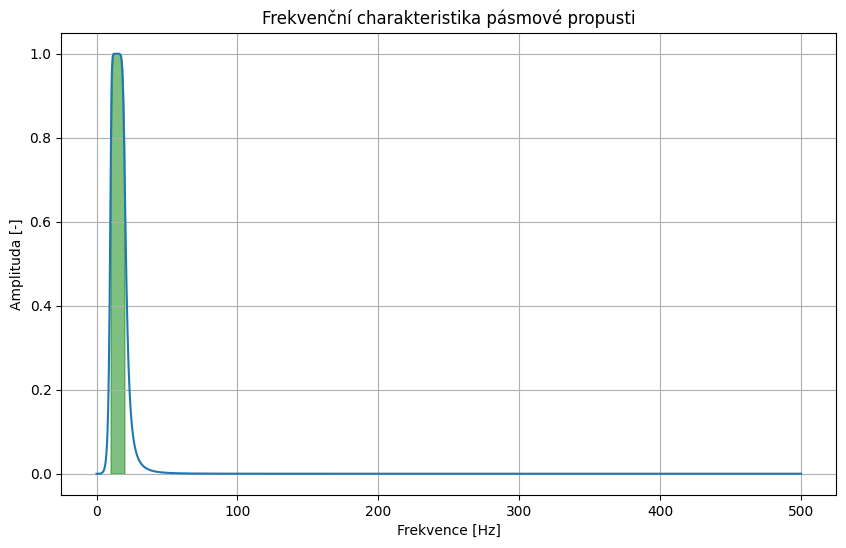

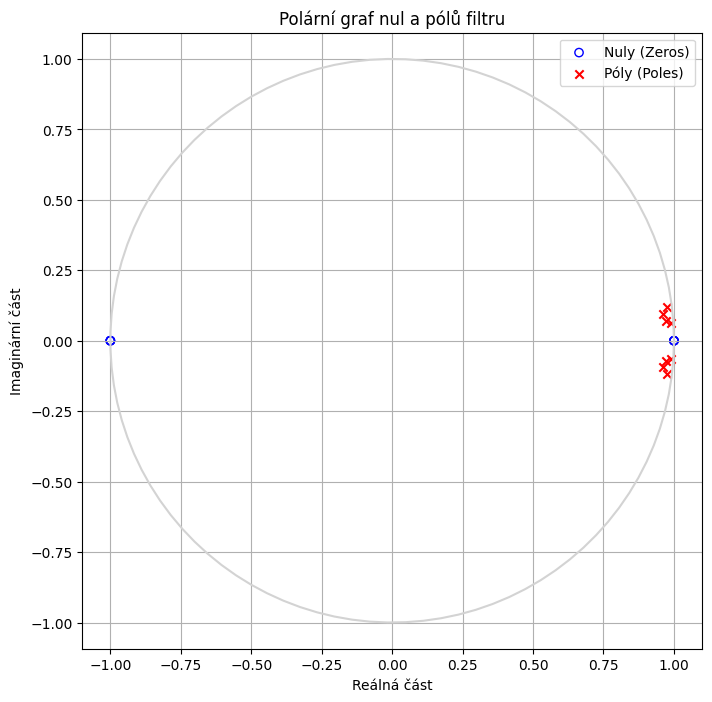

In [2]:
from scipy import signal
import matplotlib.pyplot as plt
import numpy as np

# Definujeme vzorkovací frekvenci a požadované meze pásmové propusti
fs = 1000  # Vzorkovací frekvence
lowcut = 10  # Dolní mez pásmové propusti (Hz)
highcut = 20  # Horní mez pásmové propusti (Hz)

# Návrh Butterworthova pásmového filtru
b, a = signal.butter(N=4, Wn=[lowcut, highcut], btype='band', fs=fs)

# Výpočet frekvenční charakteristiky filtru
w, h = signal.freqz(b, a, worN=2000)

# Vykreslení frekvenční charakteristiky filtru
plt.figure(figsize=(10, 6))
plt.plot(w * fs / (2 * np.pi), np.abs(h))  # Převod kmitočtu z radiánů na Hz
plt.title('Frekvenční charakteristika pásmové propusti')
plt.xlabel('Frekvence [Hz]')
plt.ylabel('Amplituda [-]')
plt.grid(True)
plt.fill_between(w * fs / (2 * np.pi), 0, np.abs(h), where=((w * fs / (2 * np.pi)) > lowcut) & ((w * fs / (2 * np.pi)) < highcut), color='green', alpha=0.5)
plt.show()

# Získání a vykreslení nul a pólů filtru
zeros, poles, k = signal.tf2zpk(b, a)

# Vykreslení polárního grafu nul a pólů
plt.figure(figsize=(8, 8))
plt.scatter(np.real(zeros), np.imag(zeros), marker='o', facecolors='none', edgecolors='blue', label='Nuly (Zeros)')
plt.scatter(np.real(poles), np.imag(poles), marker='x', color='red', label='Póly (Poles)')

# Kreslení jednotkové kružnice
angles = np.linspace(0, 2 * np.pi, 100)
plt.plot(np.cos(angles), np.sin(angles), 'lightgray')  # Jednotková kružnice

plt.title('Polární graf nul a pólů filtru')
plt.xlabel('Reálná část')
plt.ylabel('Imaginární část')
plt.grid(True)
plt.legend()
plt.axis('equal')  # Zajistí, že osy mají stejný měřítko
plt.show()


  b) [1b] Použijte navržený filtr na nahraný signál. Pokud máte navržený klasický filtr, proveďte filtrování z obou stran, abyste se vyhnuli fázovému posunu, to za vás zajistí například funkce scipy.signal.filtfilt. Vykreslete původní a vyfiltrovaný signál v časové doméně a spočítejte a zobrazte jejich spektra.


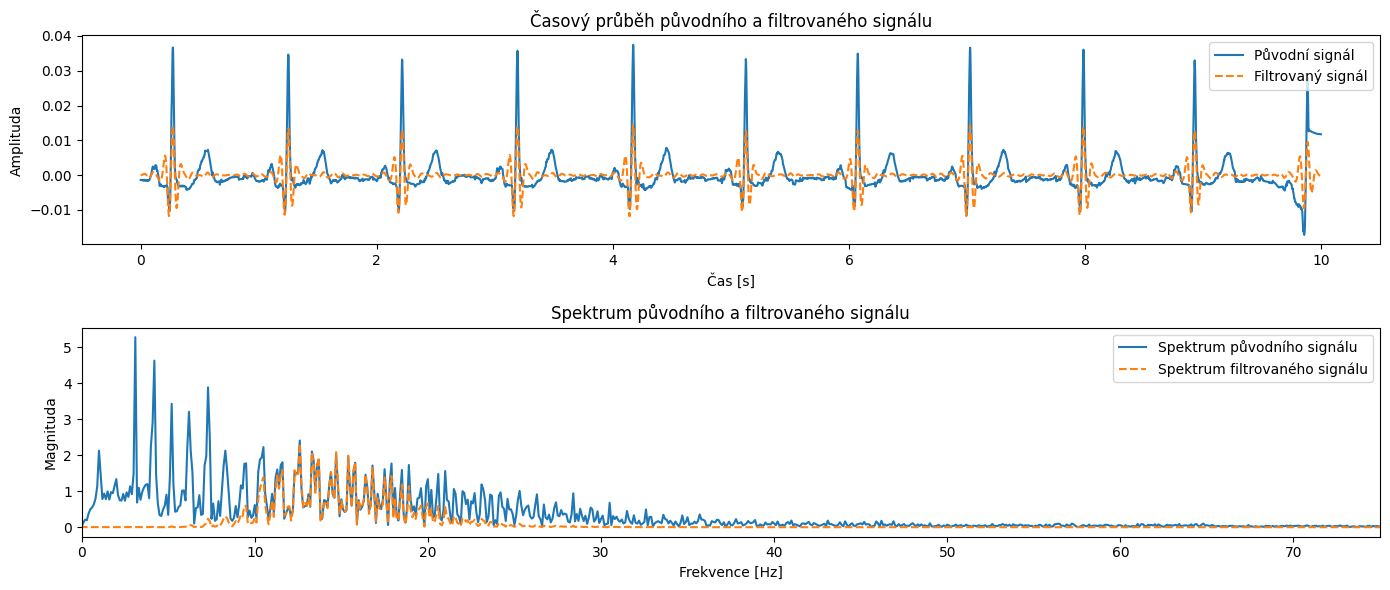

In [16]:
# Importování potřebných knihoven
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import filtfilt, butter
import soundfile as sf

# Nahrání signálu a vzorkovací frekvence ze souboru
signal, samplerate = sf.read("xteich02.wav")  # nahrazeno správnou cestou k souboru

# Nastavení požadované meze pásmové propusti
lowcut = 10  # Dolní mez pásmové propusti (Hz)
highcut = 20  # Horní mez pásmové propusti (Hz)

# Návrh Butterworthova pásmového filtru
b, a = butter(N=2, Wn=[lowcut, highcut], btype='band', fs=samplerate)

# Filtrace signálu bez fázového posunu
filtered_signal = filtfilt(b, a, signal)

# Vytvoření osy času pro signál
t = np.arange(len(signal)) / samplerate

# Výpočet spektra pro původní a filtrovaný signál
frequencies = np.fft.fftfreq(len(signal), d=1/samplerate)
spectrum_original = np.fft.fft(signal)
spectrum_filtered = np.fft.fft(filtered_signal)

# Odstranění DC složky (nulové frekvence) pro obě spektra
spectrum_original = np.fft.fftshift(spectrum_original)
spectrum_filtered = np.fft.fftshift(spectrum_filtered)
frequencies = np.fft.fftshift(frequencies)

# Vykreslení časového průběhu původního a filtrovaného signálu
plt.figure(figsize=(14, 6))
plt.subplot(2, 1, 1)
plt.plot(t, signal, label='Původní signál')
plt.plot(t, filtered_signal, label='Filtrovaný signál', linestyle='--')
plt.title('Časový průběh původního a filtrovaného signálu')
plt.xlabel('Čas [s]')
plt.ylabel('Amplituda')
plt.legend()

# Vykreslení spektra původního a filtrovaného signálu
plt.subplot(2, 1, 2)
plt.plot(frequencies, np.abs(spectrum_original), label='Spektrum původního signálu')
plt.plot(frequencies, np.abs(spectrum_filtered), label='Spektrum filtrovaného signálu', linestyle='--')
plt.title('Spektrum původního a filtrovaného signálu')
plt.xlabel('Frekvence [Hz]')
plt.ylabel('Magnituda')
plt.legend()

plt.xlim(0, 75)

plt.tight_layout()
plt.show()


  c) [1b] Okomentujte rozdíl mezi filtrovaným a nefiltrovaným signálem a jejich spektry. Pokud bychom použili filtrování pouze z jedné strany (obyčejnou konvoluci), jaké je teoreticky největší posunutí ve vzorcích, které se může objevit a proč?




Filtrovaný signál má omezené spektrální komponenty na propustné pásmo filtru, což vede k odstranění nebo potlačení frekvencí mimo toto pásmo. Nefiltrovaný signál obsahuje všechny původní frekvence, včetně nežádoucího šumu a rušení.

Teoreticky největší posunutí ve vzorcích při jednostranné filtrace by bylo rovno grupové zpoždění filtru v propustném pásmu, protože jednostranná filtrace nekompensuje fázový posun způsobený charakteristikou filtru.
*Zde napište vaše řešení.*

### 4.4. [3b] Vytvořte detektor QRS v časové doméně. Detekované QRS komplexy uložte do vhodné struktury a zároveň zobrazte graf v časové ose se zvýrazněnými QRS detekcemi.



   a) [1b] Detekujte QRS v převzorkovaném vyfiltrovaném signálu pomocí tresholdu (prahu). Pro tuto detekci musíte nejdříve získat vzorek jednoho QRS ze signálu, spočítat si maximální amplitudu a jako treshold vzít vámi určené procento této hodnoty. **Dávejte pozor na možnost otočeného QRS v signálu.** Do vykresleného signálu s detekcemi vykreslete i čáru udávající použitý treshold.

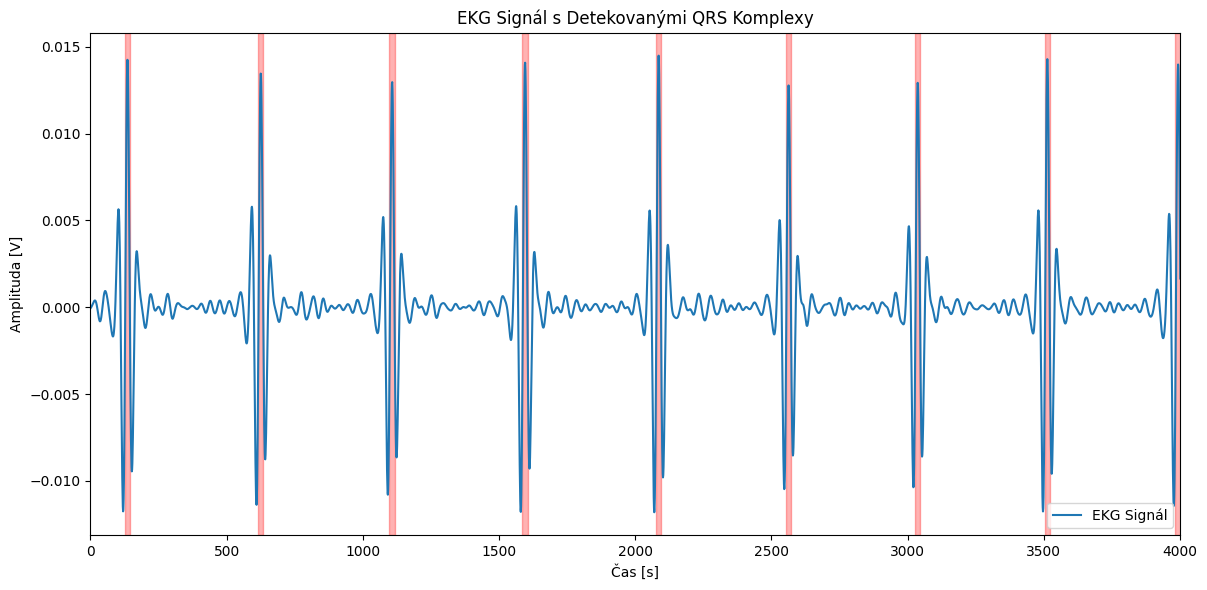

In [17]:
import soundfile as sf
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import find_peaks



# Přepočet indexů signálu na čas v sekundách
#times = np.arange(signal.size) / samplerate


sample_qrs = filtered_signal[1000:1100]

# Výpočet maximální amplitudy vzorku QRS
max_amplitude = np.max(sample_qrs)

# Stanovení thresholdu jako určitého procenta maximální amplitudy
threshold_percentage = 70
threshold = threshold_percentage / 100 * max_amplitude

# Detekce vrcholů, které by mohou představovat QRS komplexy
peaks, _ = find_peaks(filtered_signal, height=threshold, distance=samplerate/2)

# Vykreslení EKG signálu
plt.figure(figsize=(12, 6))
plt.plot(filtered_signal, label='EKG Signál')
interval_width = 5  # šířka intervalu okolo vrcholu
# Vložení červených svislých pruhů pro indikaci QRS komplexů
for peak in peaks:
    plt.axvspan(peak - 10, peak + 10, color='red', alpha=0.3)
plt.title('EKG Signál s Detekovanými QRS Komplexy')
plt.xlabel('Čas [s]')
plt.ylabel('Amplituda [V]')
plt.legend()
plt.tight_layout()


plt.xlim(0,4000)


plt.show()

b) [2b] Detekujte QRS v signálu pomocí autokorelace v převzorkovaném nefiltrovaném signálu. Pro tuto detekci musíte nejdříve získat vzorek jednoho QRS ze signálu. Dále budete autokorelovat signál právě s tímto výstřižkem. QRS se budou nacházet na místech, kde vám budou vycházet vysoké hodnoty korelace. Do vykresleného signálu s detekcemi zaznačte i vámi zvolený výstřižek.

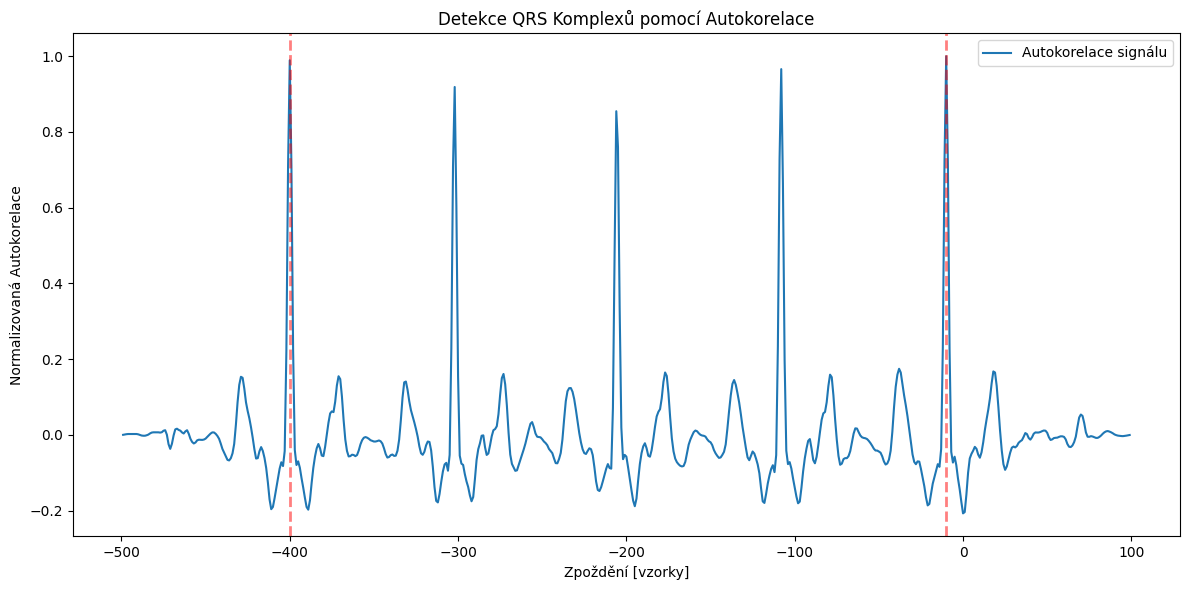

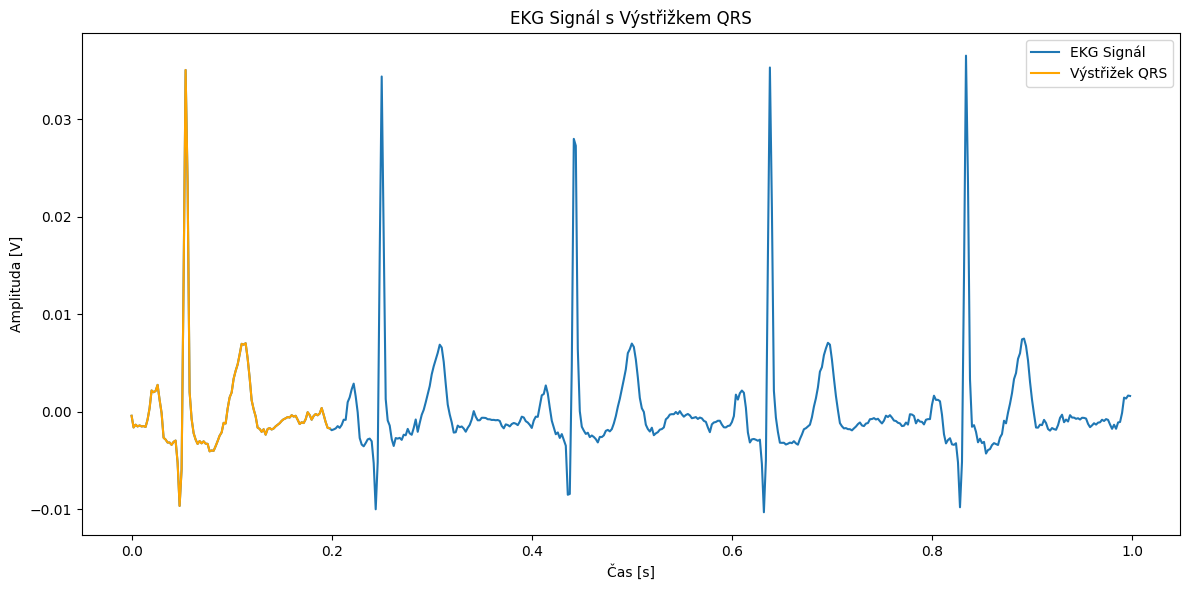

In [59]:
# Zde napište váš kód
import soundfile as sf
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import correlate, find_peaks


# Získání vzorku QRS ze signálu
sample_qrs_start = 0  # Index začátku QRS komplexu
sample_qrs_end = 100    # Index konce QRS komplexu
qrs_sample = resampled_signal[sample_qrs_start:sample_qrs_end]

# Autokorelace signálu s výstřižkem QRS
autocorrelation = correlate(resampled_signal, qrs_sample, mode='full')
autocorrelation /= np.max(autocorrelation)  # Normalizace

# Vypočítání lags pro vykreslení autokorelace
lags = np.arange(len(autocorrelation)) - (len(resampled_signal) - 1)

# Vyhledání vrcholů v autokorelaci
peaks, _ = find_peaks(autocorrelation, height=0.5, distance=samplerate/2)

# Vykreslení autokorelovaného signálu a detekovaných vrcholů
plt.figure(figsize=(12, 6))
plt.plot(lags, autocorrelation, label='Autokorelace signálu')
for peak in peaks:
    plt.axvline(x=lags[peak], color='red', linestyle='--', linewidth=2, alpha=0.5)
plt.title('Detekce QRS Komplexů pomocí Autokorelace')
plt.xlabel('Zpoždění [vzorky]')
plt.ylabel('Normalizovaná Autokorelace')
plt.legend()
plt.tight_layout()
plt.show()

# Vykreslení signálu s výstřižkem QRS
plt.figure(figsize=(12, 6))
times = np.arange(len(resampled_signal)) / samplerate
plt.plot(times, resampled_signal, label='EKG Signál')
plt.plot(times[sample_qrs_start:sample_qrs_end], qrs_sample, label='Výstřižek QRS', color='orange')
plt.title('EKG Signál s Výstřižkem QRS')
plt.xlabel('Čas [s]')
plt.ylabel('Amplituda [V]')
plt.legend()
plt.tight_layout()
plt.show()

### 4.5. [3.5b] Vytvořte detektor QRS v frekvenční doméně a detekované QRS zakreslete jako v předchozí úloze 4.4

a) [2b] Detekujte QRS pomocí použití spektrogramu. Spočítejte a zobrazte spektrogram nahraného převzorkovaného filtrovaného signálu. Použijte parametry, `hop_size=120ms`a `window_len=200ms`, popřípadě si zkuste s těmito parametry pohrát. Spektrogram dále normalizujte v čase. Spočítejte sumy energie spektra pro jednotlivé časové biny. Dále vytvořte práh podle hodnoty energie spektra u prvního vámi zvoleného QRS komplexu. Tento práh použijte pro detekci zbylých QRS komplexů v signálu.

In [ ]:
# Zde napište váš kód

b) [1b] Detekujte QRS pomocí použití obálek a Hilbertovy transformace.

Hilbertova transformace je spočítaná podle následujícího vzorce

$x_a = F^{-1}(F(x) 2U) = x + i y,$

kde F je Fourierova transformace a $F^{-1}$ je její zpětná varianta. $U$ je Heavisideova funkce neboli funkce jednotkového skoku, která je definována: $U(x):$

\begin{cases}
      0.5 & x=0 \\
      1 & 0<x<\frac{N}{2} \text{ pro  $N$  liché} \\
      0.5 & x=\frac{N}{2} \text{ pro  $N$  liché} \\
      1 & 0<x\le\frac{N}{2} \text{ pro  $N$  sudé} \\
      0 & jinak
\end{cases}

kde $N$ je počet koeficientů Fourierovy transformace - pokud není určeno jinak, je to počet vzorků signálu.

Jinými slovy obálku spočítate tak, že:

* Spočítáte FFT $F$ na filtrovaném a převzorkovaném signálu
* Vynulujete pravou symetrickou část spektra
* Levou část spektra vynasobíte 2 kromě prvního a prostředního binu (při sudém počtu frekvenčních binů).
* Provedete zpětnou FFT $F^{-1}$

Abyste získali obálku signálu, je třeba vzít absolutní hodnotu signálu získaného Hilbertovou transformací.

Obálku a signál vykreslete do jednoho grafu přes sebe, obálka by měla obalovat daný signál.

In [ ]:
# Zde napište váš kód

c) [0.5b] Při kterých metodách detekcí QRS nám vadí otočený (flipnutý) signál, při kterých ne a proč?

Porblém může být u algoritmů, které hledají specifickou polaritu QRS komplexů, například pozitivní špičky R vzhledem k baseline. Metody založené na amplitudě nebo tvaru, které předpokládají konkrétní orientaci QRS komplexu, budou narušeny, protože obrácení signálu změní orientaci komplexů.

Metody, které se spoléhají na energetické charakteristiky, jako jsou RMS nebo algoritmy založené na transformacích nezávislých na fázi (např. Wavelet transformace), mohou být na obrácení signálu imunní, protože zachovávají celkovou energii QRS komplexů bez ohledu na jejich polaritu.

### 4.6 [2b] Detekce R-R intervalu

a)  Detekujte R-R intervaly pomocí detekovaných QRS z jednotlivých metod, které jste použili dříve. Vykreslete hodnoty R-R intervalu do stejného grafu jako EKG signál a detekované QRS. Vykreslení proveďte nad EKG signál, kde osa x bude i nadále časová a každý R-R interval bude zakreslen na x pozici detekovaného QRS. Osa y pro R-R interval bude určovat hodnotu samotného R-R intervalu.

Mělo by to vypadat přibližně takto (před odevzdáním smažte):
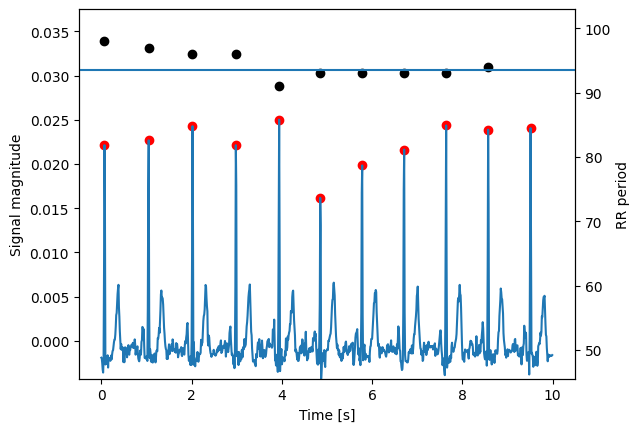

In [ ]:
# Zde napište váš kód

### 4.7 Bonus

a) Načtěte si signál obsahující fibrilaci FIS.wav. Proveďte na něm filtrace a převzorkování. Poté zkuste použít nějaký QRS detektor. Z detekovaných QRS detekujte R-R intervaly. Porovnejte R-R intervaly pro fibrilaci a klasický signál bez patologie (sinusovy rytmus). Měli byste vidět prudké změny v R-R intervalech a jejich nepravidelnost. Zároveň se vám může stát, že vám některé metody detekce QRS nepodají tak kvalitní výkon jako při sinusovém rytmu.

In [ ]:
# Zde napište váš kód

b) Načtěte si signál obsahující komorovou extrasystolu KES.wav. Proveďte na něm filtrace a převzorkování. Spočítejte a zobrazte spektrogram úseku tohoto signálu. Porovnejte spektrogramy vašeho signálu a signálu KES.wav. Měli byste vidět rozšířenou aktivitu na nízkých frekvencích. Dále zobrazte a porovnejte tyto signály v časové doméně. Obsažené komorové extrasystoly by se měly projevit jako zvláštní široké QRS.

In [ ]:
# Zde napište váš kód